<a href="https://colab.research.google.com/github/yaRiick/PubChem-analysis/blob/main/pubchem_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) of a Large-Scale Chemical Dataset (PubChem)

## About the Project
In modern data analytics, the ability to process specific “raw” formats, clean them, and uncover hidden patterns is a key skill. This project is a full-fledged end-to-end analytical pipeline for non-standard data.

This work involves the analysis of a large dataset (nearly 2 million records) from the open-access PubChem database. Instead of traditional financial transactions or user logs, this project analyzes the physicochemical properties of molecules, which requires specialized parsing and in-depth exploratory data analysis (EDA).

## Analytical objectives of the project:
1. **Data Extraction & Preprocessing:** Parsing complex raw files in the `.sdf.gz` format, extracting numerical features using `RDKit`, and constructing a structured `Pandas` DataFrame with 2 million rows.
2. **Exploratory Data Analysis (EDA):** Investigating data distribution, identifying and handling statistical outliers, and filtering the dataset based on specified logical conditions.
3. **Business Analytics (ABC Analysis):** Applying a classic business tool (the Pareto 80/20 principle) to atypical data. Segmenting the dataset to test the hypothesis of uniformity in the distribution of values within the dataset.
4. **Statistics and Visualization:** Checking data for multicollinearity (constructing a Pearson correlation heatmap), analysis of variance, and visualization of trends using `Seaborn` tools.

## Stack:
* **Data Manipulation:** Python (Pandas, NumPy)
* **Data Visualization:** Matplotlib, Seaborn
* **Data Parsing (Domain Specific):** RDKit
---

In [ ]:
# add the necessary libraries
!pip install rdkit
import gzip
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import RDLogger
import scipy.stats as stats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 20.9 MB/s eta 0:00:00


In [ ]:
# Suppress RDKit warnings for corrupted molecules to keep the console output clean
RDLogger.DisableLog('rdApp.*')

# Define paths to raw compressed SDF files stored on Google Drive
file_paths = [
    '/content/drive/MyDrive/Rdkit/PubChem Data/Compound_000000001_000500000.sdf.gz',
    '/content/drive/MyDrive/Rdkit/PubChem Data/Compound_003500001_004000000.sdf.gz',
    '/content/drive/MyDrive/Rdkit/PubChem Data/Compound_004500001_005000000.sdf.gz',
    '/content/drive/MyDrive/Rdkit/PubChem Data/Compound_005000001_005500000.sdf.gz'
]

data = []

# Iterate through each compressed file and extract physicochemical descriptors
for current_file in file_paths:
  with gzip.open(current_file, 'rb') as gz:
    suppl = Chem.ForwardSDMolSupplier(gz)

    for i, mol in enumerate(suppl):
      # Skip invalid or corrupted molecule records
      if mol is None: continue

      # Extract core features required for Lipinski's Rule and EDA
      row = {
          'cid': mol.GetProp("_Name") if mol.HasProp('_Name') else i,
          'smiles': Chem.MolToSmiles(mol),
          'mol_weight': Descriptors.MolWt(mol),
          'logp': Descriptors.MolLogP(mol),
          'HBD': Descriptors.NumHDonors(mol),
          'HBA': Descriptors.NumHAcceptors(mol)
      }
      data.append(row)

      # Track parsing progress
      if i % 10000 == 0:
          print(f"{i} molecules processed in the current batch")

# Convert the extracted data into a Pandas DataFrame
df = pd.DataFrame(data)
output_path = '/content/drive/MyDrive/Rdkit/pubchem_properties.csv'

# Export the consolidated dataset to CSV for future analysis (prevents re-parsing)
df.to_csv(output_path, index=False, encoding='utf-8')
print("The file has been successfully saved to Google Drive!")


0 molecules processed in the current batch
10000 molecules processed in the current batch
20000 molecules processed in the current batch
30000 molecules processed in the current batch
40000 molecules processed in the current batch
50000 molecules processed in the current batch
60000 molecules processed in the current batch
70000 molecules processed in the current batch
80000 molecules processed in the current batch
90000 molecules processed in the current batch
100000 molecules processed in the current batch
110000 molecules processed in the current batch
120000 molecules processed in the current batch
130000 molecules processed in the current batch
140000 molecules processed in the current batch
150000 molecules processed in the current batch
160000 molecules processed in the current batch
170000 molecules processed in the current batch
180000 molecules processed in the current batch
190000 molecules processed in the current batch
200000 molecules processed in the current batch
210000

In [ ]:
# 1. Inspect dataset structure, data types, and memory usage
print("--- Dataset Info ---")
df.info()
print("-" * 40)

# 2. Identify missing values (NaNs) that could break downstream statistical analysis
print("\n--- Missing Values ---")
print(f"Number of Null values per column:\n{df.isna().sum()}")
print("-" * 40)

# 3. Check for fully duplicated records to prevent skewed distributions
print("\n--- Duplicates ---")
print(f"Total duplicated rows: {df.duplicated().sum()}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1829592 entries, 0 to 1829591
Data columns (total 6 columns):
 #   Column      Dtype  
---  ------      -----  
 0   cid         object 
 1   smiles      object 
 2   mol_weight  float64
 3   logp        float64
 4   HBD         int64  
 5   HBA         int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 83.8+ MB
----------------------------------------

--- Missing Values ---
Number of Null values per column:
cid           0
smiles        0
mol_weight    0
logp          0
HBD           0
HBA           0
dtype: int64
----------------------------------------

--- Duplicates ---
Total duplicated rows: 0


In [ ]:
# Anomaly Detection (Outliers Analysis)
# ==========================================

# --- Molecular Weight Analysis ---
# Sanity check: verify data integrity (molecular weight cannot be negative)
anomaly_mol_weight_less_than_0 = df[df['mol_weight'] < 0]
print(f"Molecules that weigh less than zero:\n{anomaly_mol_weight_less_than_0}\n")

# Inspect the extreme upper tail of the weight distribution (potential macrocycles or parsing errors)
anomaly_top10_mol_weight = df.sort_values(by='mol_weight', ascending=False)
print(f"Top 10 heaviest molecules:\n{anomaly_top10_mol_weight[['mol_weight', 'logp']].head(10)}\n")


# --- LogP (Lipophilicity) Analysis ---
# Inspect LogP extremes to identify highly lipophilic (high positive) or highly hydrophilic (high negative) outliers
anomaly_top10_logp = df.sort_values(by='logp', ascending=False)
print(f"Top 10 molecules with the highest LogP (extremely lipophilic):\n{anomaly_top10_logp[['mol_weight', 'logp']].head(10)}\n")

anomaly_last_top10_logp = df.sort_values(by='logp', ascending=True)
print(f"Top 10 molecules with the lowest LogP (extremely hydrophilic):\n{anomaly_last_top10_logp[['mol_weight', 'logp']].head(10)}")


Molecules that weigh less than zero:
Empty DataFrame
Columns: [cid, smiles, mol_weight, logp, HBD, HBA]
Index: []

Top 10 heaviest molecules:
         mol_weight      logp
175202    18838.697  -0.24500
102292    18656.858   6.55270
406503     7919.386 -85.23470
432997     7112.315 -62.31400
432996     6549.262 -73.77200
1828229    6259.040 -55.94760
23154      6179.373 -83.66680
175451     5907.232  -0.25000
407221     5728.919 -31.35440
1670908    5725.952  50.26206

Top 10 molecules with the highest LogP (extremely lipophilic):
         mol_weight      logp
376761     2476.316  59.80872
174899     2750.733  55.23740
1670908    5725.952  50.26206
90957      2474.049  49.10360
385051     2474.049  49.10360
377766     2460.022  49.06110
1571704    2992.734  47.87160
67057      2249.617  42.86200
377765     2249.617  42.86200
155603     1830.866  40.74816

Top 10 molecules with the lowest LogP (extremely hydrophilic):
         mol_weight     logp
411115     3277.953 -88.9721
406499     5

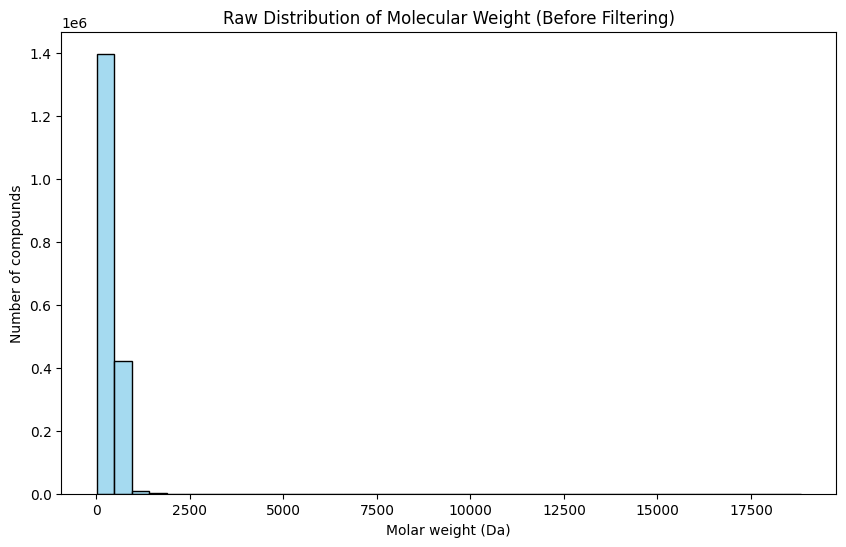

--- Descriptive Statistics (Raw Data) ---
Molar weight spread (Range): 18838 Da
Average molar weight: 398 Da
Median molar weight: 390 Da

Number of statistical anomalies (Z-score > 3): 22996



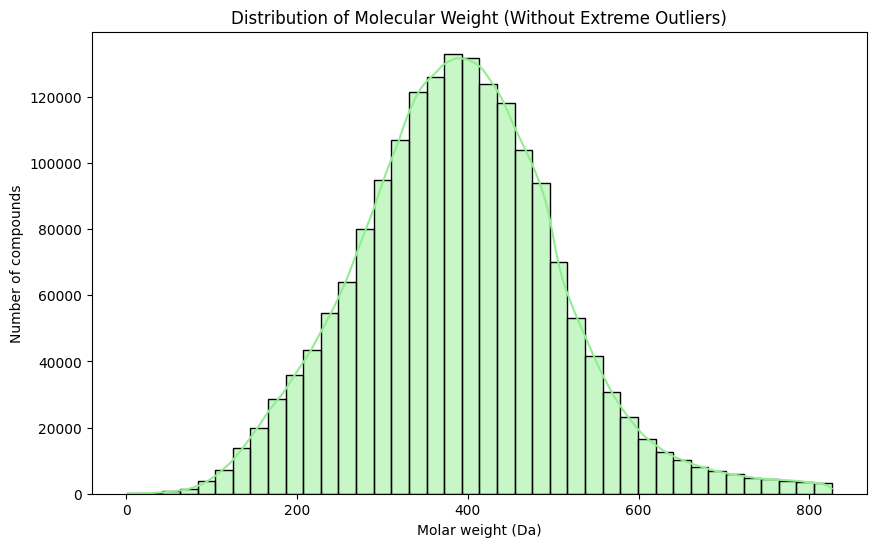

--- Distribution Shape Statistics (Cleaned Data) ---
Skewness: 0.320 (Measures the asymmetry of the distribution)
Kurtosis: 0.507 (Measures the 'tailedness' or peakness relative to normal distribution)


In [ ]:
# ==========================================
# Distribution Analysis & Outlier Handling
# ==========================================
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize the raw distribution of molecular weight
# This often reveals a heavily right-skewed distribution due to extreme outliers (e.g., macrocycles)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='mol_weight', bins=40, color='skyblue')
plt.xlabel('Molar weight (Da)')
plt.ylabel('Number of compounds')
plt.title('Raw Distribution of Molecular Weight (Before Filtering)')
plt.show()

# 2. Calculate baseline descriptive statistics
disp = df['mol_weight'].max() - df['mol_weight'].min()
average_mol_weight = df['mol_weight'].mean()
median_mol_weight = df['mol_weight'].median()

print("--- Descriptive Statistics (Raw Data) ---")
print(f"Molar weight spread (Range): {disp:.0f} Da")
print(f"Average molar weight: {average_mol_weight:.0f} Da")
print(f"Median molar weight: {median_mol_weight:.0f} Da\n")

# 3. Apply the 3-Sigma Rule (Z-score > 3) to identify mathematical anomalies
# We calculate z-scores once to optimize performance on large datasets
z_scores = abs(stats.zscore(df['mol_weight'], nan_policy='omit'))
anomaly_mask = z_scores > 3

anomaly_count = df[anomaly_mask].shape[0]
print(f"Number of statistical anomalies (Z-score > 3): {anomaly_count}\n")

# 4. Filter out the extreme outliers and plot the cleaned distribution
# Adding KDE (Kernel Density Estimate) to visualize the smooth shape of the distribution
cleared_df = df[~anomaly_mask]

plt.figure(figsize=(10, 6))
sns.histplot(data=cleared_df, x='mol_weight', bins=40, kde=True, color='lightgreen')
plt.xlabel('Molar weight (Da)')
plt.ylabel('Number of compounds')
plt.title('Distribution of Molecular Weight (Without Extreme Outliers)')
plt.show()

# 5. Calculate advanced shape statistics on the cleaned dataset
skewness = cleared_df['mol_weight'].skew()
kurtosis = cleared_df['mol_weight'].kurt()

print("--- Distribution Shape Statistics (Cleaned Data) ---")
print(f"Skewness: {skewness:.3f} (Measures the asymmetry of the distribution)")
print(f"Kurtosis: {kurtosis:.3f} (Measures the 'tailedness' or peakness relative to normal distribution)")

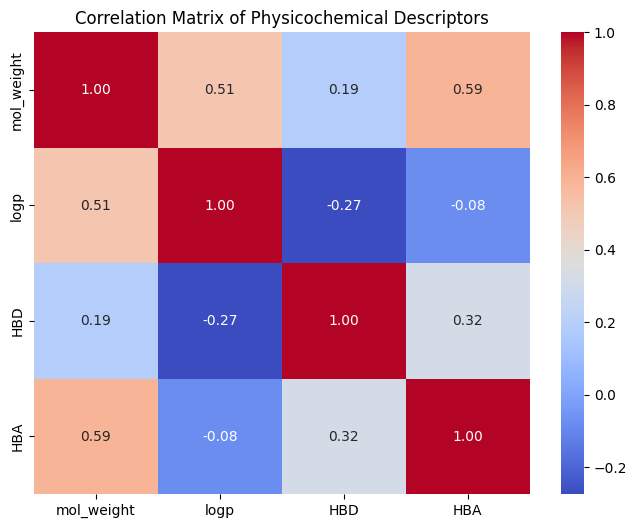

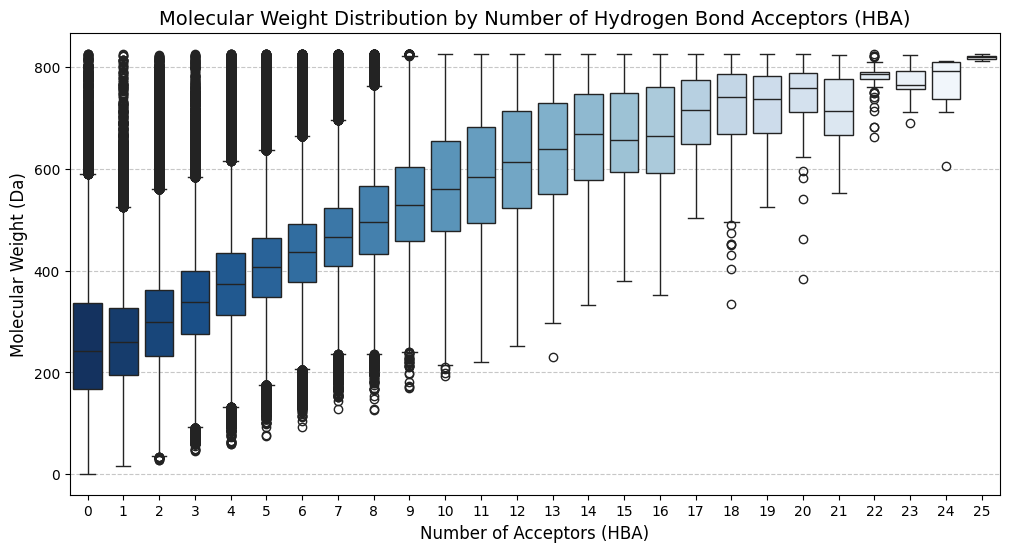

In [ ]:
# ==========================================
# Feature Correlation & Bivariate Analysis
# ==========================================

# 1. Correlation Matrix (Heatmap)
# Check for multicollinearity between physicochemical properties.
# We use 'cleared_df' (without extreme outliers) to prevent Pearson coefficients from being artificially skewed.
plt.figure(figsize=(8, 6))
sns.heatmap(cleared_df[['mol_weight', 'logp', 'HBD', 'HBA']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Physicochemical Descriptors')
plt.show()


# 2. Bivariate Analysis: Molecular Weight vs. HBA (Boxplot)
# Filter out sparse right-tail records (HBA > 25) to prevent chart distortion and focus on the main distribution.
df_filtered = cleared_df[cleared_df['HBA'] <= 25]

plt.figure(figsize=(12, 6))
# Boxplots effectively reveal both the median shift and the increasing variance of mass as heteroatoms increase
sns.boxplot(
    data=df_filtered,
    x='HBA',
    y='mol_weight',
    hue='HBA',
    palette='Blues_r',
    legend=False
)

plt.title('Molecular Weight Distribution by Number of Hydrogen Bond Acceptors (HBA)', fontsize=14)
plt.xlabel('Number of Acceptors (HBA)', fontsize=12)
plt.ylabel('Molecular Weight (Da)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

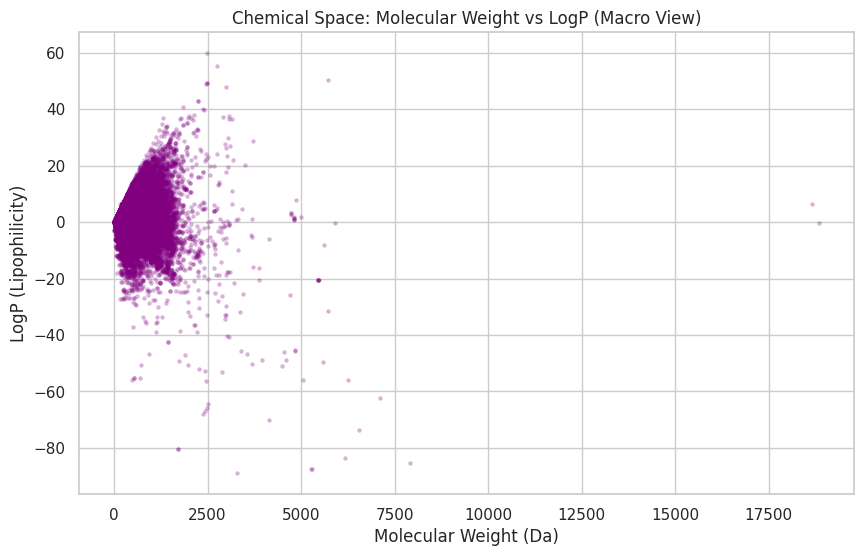

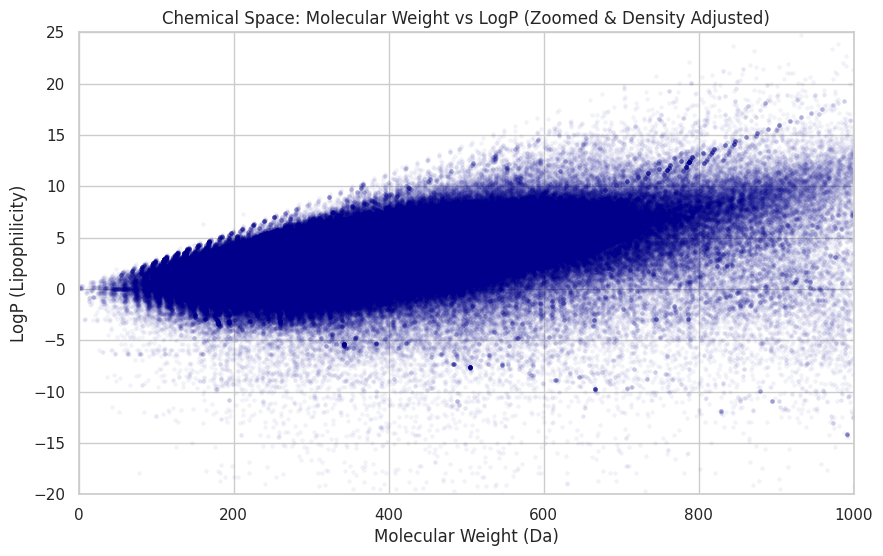

In [ ]:
# ==========================================
# Chemical Space Exploration (Scatter Plots)
# ==========================================

# Set a clean visual theme for all subsequent plots
sns.set_theme(style="whitegrid")

# 1. Macro View: Full Dataset Scatter Plot
# Visualizing the entire dataset to observe the extreme outliers.
# High overplotting is expected here due to the ~2M row volume.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mol_weight', y='logp', alpha=0.3, s=10, linewidth=0, color='purple')
plt.title("Chemical Space: Molecular Weight vs LogP (Macro View)")
plt.xlabel("Molecular Weight (Da)")
plt.ylabel("LogP (Lipophilicity)")
plt.show()

# 2. Micro View: Focused Chemical Space
# Zooming into the most dense region by limiting axes.
# Using a very low alpha (0.05) to reveal the actual density gradient of overlapping points.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='mol_weight', y='logp', alpha=0.05, s=10, linewidth=0, color='darkblue')
plt.xlim(0, 1000)
plt.ylim(-20, 25)
plt.title("Chemical Space: Molecular Weight vs LogP (Zoomed & Density Adjusted)")
plt.xlabel("Molecular Weight (Da)")
plt.ylabel("LogP (Lipophilicity)")
plt.show()

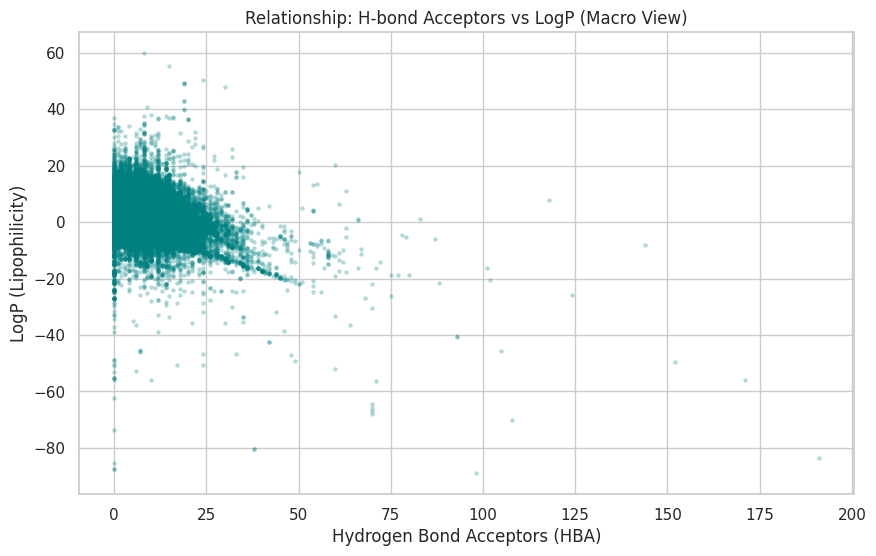

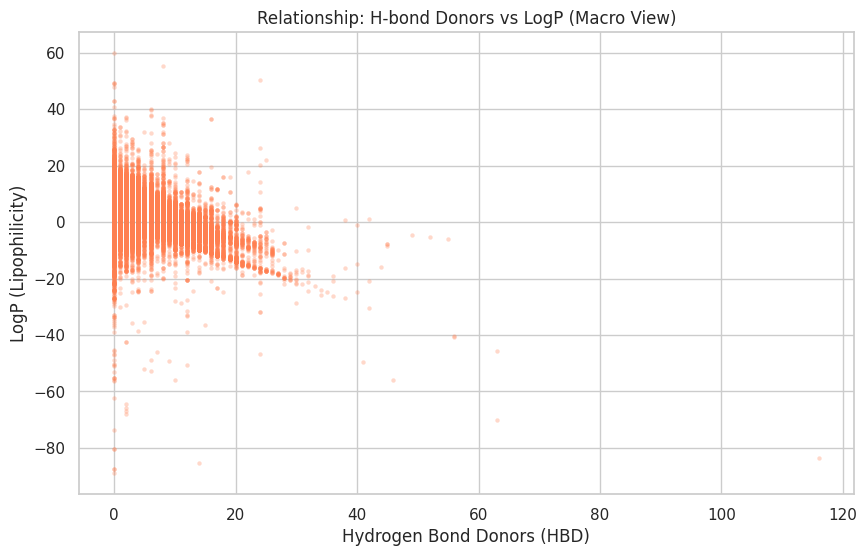

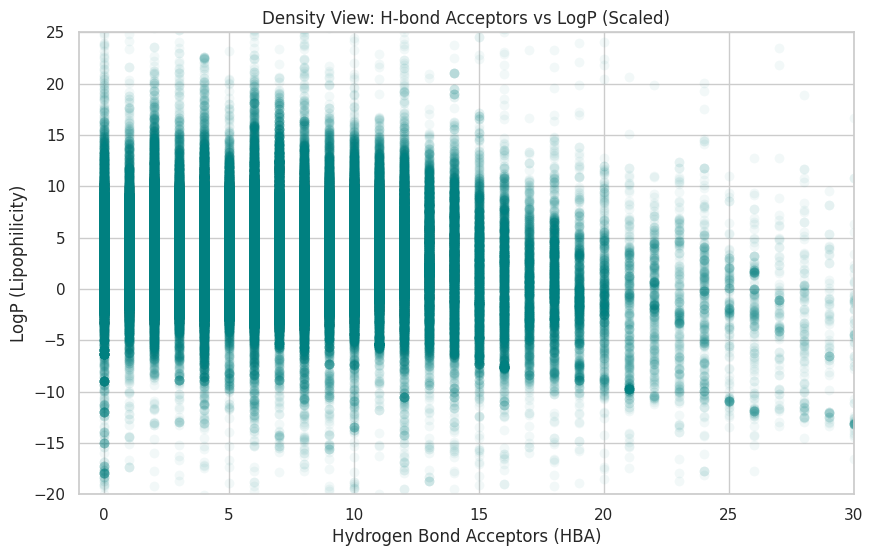

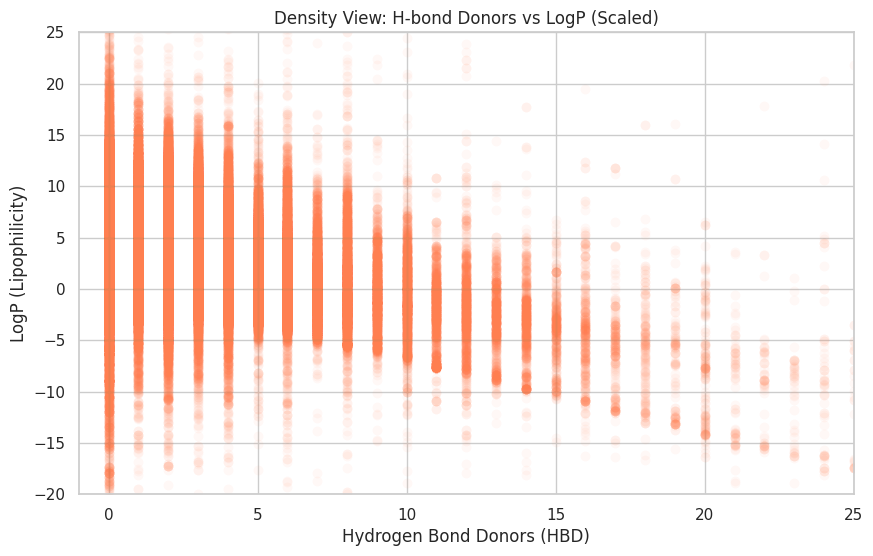

In [ ]:
# ==========================================
# Relationship: Hydrogen Bonding vs Lipophilicity (LogP)
# ==========================================
# Hypothesis check: Increasing the number of hydrogen bond donors/acceptors (polar groups)
# typically decreases LogP (makes the molecule more water-soluble/hydrophilic).

# 1. Macro View: Full Dataset
# Visualizing the global trend and extreme outliers for HBA and HBD against LogP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='HBA', y='logp', alpha=0.3, s=10, linewidth=0, color='teal')
plt.title("Relationship: H-bond Acceptors vs LogP (Macro View)")
plt.xlabel("Hydrogen Bond Acceptors (HBA)")
plt.ylabel("LogP (Lipophilicity)")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='HBD', y='logp', alpha=0.3, s=10, linewidth=0, color='coral')
plt.title("Relationship: H-bond Donors vs LogP (Macro View)")
plt.xlabel("Hydrogen Bond Donors (HBD)")
plt.ylabel("LogP (Lipophilicity)")
plt.show()

# 2. Micro View: Dense Chemical Space (Scaled)
# Adjusting axis limits to exclude sparse outliers and lowering alpha (0.05)
# to reveal the true density distribution of the majority of compounds.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='HBA', y='logp', alpha=0.05, s=50, linewidth=0, color='teal')
plt.title("Density View: H-bond Acceptors vs LogP (Scaled)")
plt.xlabel("Hydrogen Bond Acceptors (HBA)")
plt.ylabel("LogP (Lipophilicity)")
plt.xlim(-1, 30)
plt.ylim(-20, 25)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='HBD', y='logp', alpha=0.05, s=50, linewidth=0, color='coral')
plt.title("Density View: H-bond Donors vs LogP (Scaled)")
plt.xlabel("Hydrogen Bond Donors (HBD)")
plt.ylabel("LogP (Lipophilicity)")
plt.xlim(-1, 25)
plt.ylim(-20, 25)
plt.show()

In [ ]:
# ==========================================
# Drug-Likeness Assessment (Lipinski's Rule of Five)
# ==========================================
# Evaluating theoretical oral bioavailability criteria:
# MW < 500 Da, LogP < 5, H-Bond Donors <= 5, H-Bond Acceptors <= 10

total_compounds = len(df)

# 1. Canonical Lipinski's Rule Check
# Strict adherence to the original rule definition
lipinski_strict = df[
    (df['mol_weight'] < 500) &
    (df['logp'] < 5) &
    (df['HBD'] <= 5) &
    (df['HBA'] <= 10)
]

strict_pct = (len(lipinski_strict) / total_compounds) * 100
print(f"Canonical Lipinski compliance: {len(lipinski_strict):,} compounds ({strict_pct:.1f}% of total)")


# 2. Realistic Drug-Likeness Check
# Adding a lower bound for lipophilicity (LogP >= 0).
# Extremely hydrophilic molecules (negative LogP) generally struggle to cross lipid cell membranes.
lipinski_realistic = df[
    (df['mol_weight'] < 500) &
    (df['logp'] >= 0) & (df['logp'] < 5) &
    (df['HBD'] <= 5) &
    (df['HBA'] <= 10)
]

real_pct = (len(lipinski_realistic) / total_compounds) * 100
print(f"Realistic Lipinski compliance (LogP >= 0): {len(lipinski_realistic):,} compounds ({real_pct:.1f}% of total)")

Canonical Lipinski compliance: 1,262,115 compounds (69.0% of total)
Realistic Lipinski compliance (LogP >= 0): 1,200,792 compounds (65.6% of total)


--- Row Distribution by ABC Class ---
category
A    69.17%
B    20.38%
C    10.44%
Name: proportion, dtype: object
----------------------------------------


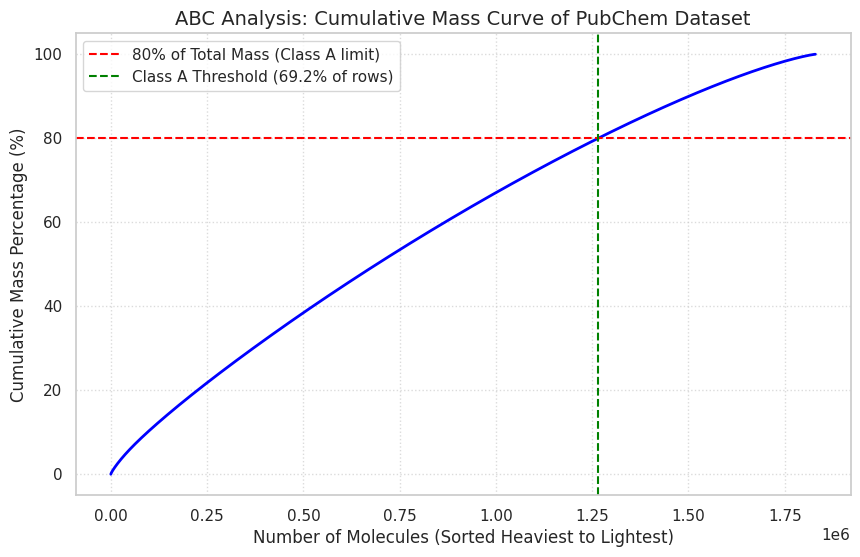

In [ ]:
# ==========================================
# Business Logic Application: ABC Analysis (Pareto Principle)
# ==========================================
# Applying standard inventory categorization (ABC) to a chemical dataset.
# Goal: Check if a small fraction of molecules (e.g., 20%) accounts for
# the majority (80%) of the total dataset mass, or if the distribution is uniform.

# 1. Sort dataset from heaviest to lightest to build the cumulative curve
df_abc = df.sort_values(by='mol_weight', ascending=False).copy()

# 2. Calculate cumulative mass and its percentage relative to the total mass
df_abc['cumsum'] = df_abc['mol_weight'].cumsum()
total_weight = df_abc['mol_weight'].sum()
df_abc['cum_pct'] = (df_abc['cumsum'] / total_weight) * 100

# 3. Categorize compounds based on cumulative mass contribution
# Class A: Top 80% of total mass
# Class B: Next 15% of total mass (80% - 95%)
# Class C: Bottom 5% of total mass (95% - 100%)
def assign_category(pct):
    if pct <= 80:
        return 'A'
    elif pct <= 95:
        return 'B'
    else:
        return 'C'

df_abc['category'] = df_abc['cum_pct'].apply(assign_category)

# Display the proportion of rows in each class
print("--- Row Distribution by ABC Class ---")
abc_distribution = df_abc['category'].value_counts(normalize=True) * 100
print(abc_distribution.apply(lambda x: f"{x:.2f}%"))
print("-" * 40)

# 4. Visualize the ABC Cumulative Curve
plt.figure(figsize=(10, 6))

# Plot the cumulative percentage curve using row indices (0 to N)
plt.plot(df_abc['cum_pct'].values, color='blue', linewidth=2)

# Dynamically calculate the cutoff point for Class A to avoid hardcoded values
class_a_count = len(df_abc[df_abc['category'] == 'A'])
class_a_pct = (class_a_count / len(df_abc)) * 100

# Add dynamic reference lines
plt.axhline(y=80, color='red', linestyle='--', label='80% of Total Mass (Class A limit)')
plt.axvline(x=class_a_count, color='green', linestyle='--',
            label=f'Class A Threshold ({class_a_pct:.1f}% of rows)')

plt.title('ABC Analysis: Cumulative Mass Curve of PubChem Dataset', fontsize=14)
plt.xlabel('Number of Molecules (Sorted Heaviest to Lightest)', fontsize=12)
plt.ylabel('Cumulative Mass Percentage (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [ ]:
# ==========================================
# Final Data Preparation & Export for BI
# ==========================================
from scipy import stats
from IPython.display import display

# 1. Flag Statistical Anomalies (Outliers)
# Instead of deleting outliers, we create a boolean flag ('is_anomaly').
# This preserves the dataset's integrity (Single Source of Truth) while allowing
# end-users to dynamically filter outliers in BI tools like Tableau or Power BI.
df_abc['is_anomaly'] = abs(stats.zscore(df_abc['mol_weight'], nan_policy='omit')) > 3

# Preview the final dataset structure before exporting
print("--- Final Dataset Preview (Top Heavy Molecules) ---")
display(df_abc[['cid', 'smiles', 'mol_weight', 'category', 'is_anomaly']].head())

# 2. Export the enriched dataset
export_path = 'pubchem_processed_data.csv'
df_abc.to_csv(export_path, index=False)

print(f"\n Success: The cleaned and enriched dataset has been saved to '{export_path}'")

--- Final Dataset Preview (Top Heavy Molecules) ---


,cid,smiles,mol_weight,category,is_anomaly
175202,194416,[Au].[Au].[Au].[Au].[Au].[Au].[Au].[Au].[Au].[...,18838.697,A,True
102292,111615,CCN(CC)c1ccc(C(=C2C=CC(=[N+](CC)CC)C=C2)c2ccc(...,18656.858,A,True
406503,452325,O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O....,7919.386,A,True
432997,485461,O.O.O.O.O.O.O.O.[Eu+3].[Eu+3].[Eu+3].[K+].[K+]...,7112.315,A,True
432996,485460,O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O.O....,6549.262,A,True



 Success: The cleaned and enriched dataset has been saved to 'pubchem_processed_data.csv'
